In [1]:
from pathlib import Path

import numpy as np
from matplotlib import pyplot as plt
from joblib import Parallel, delayed
from tqdm import tqdm
import imageio
from IPython.display import Image


from lrv_test.known_functions import X_MINUS_1_SQUARE

from lrv_test import LRVConfig, LRV, LRVResult

from statsmodels.tsa.arima_process import arma_generate_sample

import seaborn as sns 
sns.set_style("whitegrid")

In [2]:
lrv_config = LRVConfig(B=101,
                    L=4,
                    f= X_MINUS_1_SQUARE,
                    n_max_freqs=100)

# the complex gaussian time series will be ARMA(1,1) with the following parameters
ar = 0.5
ma = 0
N = 500  # number of samples
M = 50  # number of time series
burn = 100

c = M / N

def run() -> LRVResult:
    real = arma_generate_sample([1, -ar], [1, ma], (N + burn, M), scale=1 / np.sqrt(2))
    imag = arma_generate_sample([1, -ar], [1, ma], (N + burn, M), scale=1 / np.sqrt(2))
    y = real + 1j * imag
    assert y.shape == (N + burn, M)
    return LRV(y[burn:], lrv_config)


# Generate a large number of experiments
n_repeat = 10
results = Parallel(n_jobs=1)(delayed(run)() for _ in tqdm(range(n_repeat)))

  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [02:48<00:00, 16.80s/it]


# With oracle spectral density

In [3]:
def _AR_spectral_density(ar: float) -> callable:
    return lambda nu: (1 + ar**2 - 2 * ar * np.cos(2 * np.pi * nu)) ** -1

def _MA_spectral_density(ma: float) -> callable:
    return lambda nu: 1 + ma**2 + 2 * ma * np.cos(2 * np.pi * nu)
                    
# we will also need to provide the spectral density of the ARMA(1,1) process. It can also be computed
# from the sample time series.
def _ARMA_spectral_density(ar: float, ma: float) -> callable:
    ma_part = _MA_spectral_density(ma)
    ar_part = _AR_spectral_density(ar)
    return lambda nu: ar_part(nu) * ma_part(nu)

oracle_sd = _ARMA_spectral_density(ar, ma)

# Corrective term
In this notebook we check that the corrective terms computed in the paper are matching with lss - int f d_mp 

In [4]:
M = 100

# oracle spectral density of y
oracle_sd = ARMA_spectral_density(data_gen_config.ars, data_gen_config.mas)

lrv_config = LRVConfig(B=301, 
                L=10, 
                f= lambda x: (x-1)**2,
                n_max_freqs=100)
lrv_result = LRV(y, lrv_config, oracle_sd) # oracle_sd is optional, used here to check the aligmnent with the lag window estimator


# plot for each nu the LSSS of the estimated spectral coherency 
# against the Marchenko-Pastur distribution and the corrective terms
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(lrv_result.freqs, lrv_result.lsss - lrv_result.f_mp - lrv_result.correction_term_2, label='LSSS - f(MP) + D_n * 1/c_n * 1/B', marker='o')
ax.plot(lrv_result.freqs, lrv_result.correction_term_1, label='D_n * r_n * v_n')
ax.plot(lrv_result.freqs, lrv_result.correction_term_1_hat, label='D_n * r_n_hat * v_n', marker='o')
ax.set_xlabel('Frequency')
ax.set_ylabel('Value')
ax.set_title('LSSS against the Marcenko-Pastur distribution')
ax.legend()
plt.show()

Path('./plots/correction').mkdir(parents=True, exist_ok=True)
fig.savefig('./plots/correction.png', bbox_inches='tight')

NameError: name 'ARMA_spectral_density' is not defined

100%|██████████| 7/7 [00:00<00:00, 779.59it/s]
/var/folders/p4/9hslrdhx3ys_svm2892373jc0000gn/T/ipykernel_85649/1702301156.py:59: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images = [imageio.imread(f'./plots/correction/{result.N}.png') for result in results]


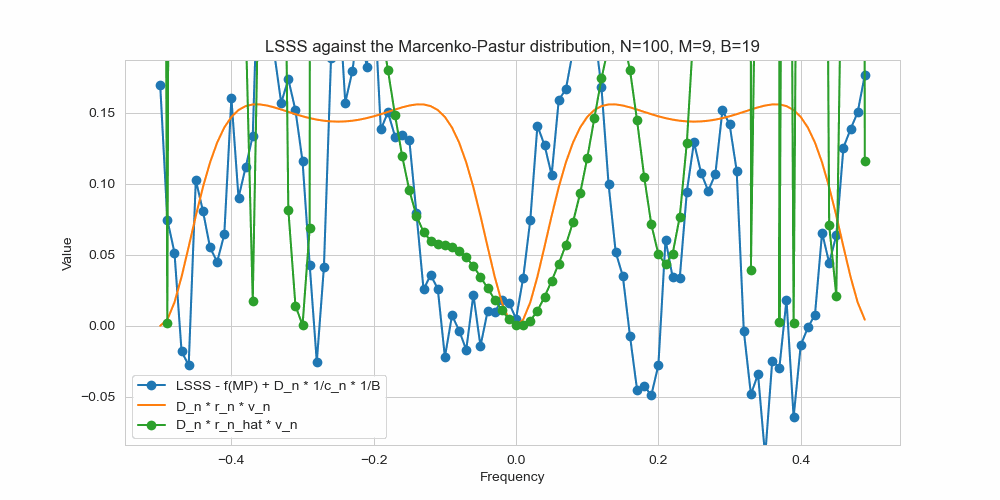

In [ ]:
# same figure for a range of increasing N, while M and B scales in the setting defined in the paper 
N_range = np.arange(100, 3100, 300)
alpha, c = 0.8, 0.5

configs = [] 
for N in N_range: 
    M = int(N ** alpha / 4)
    B = int(M / c)
    if B % 2 == 0: # force B to be odd
        B += 1

    ars = np.random.uniform(low=0.5, high=0.5, size=M)
    mas = np.random.uniform(low=0.5, high=0.5, size=M)

    L = round(np.log(N))

    data_gen_config = DataGenConfig(N=N, 
                    M=M, 
                    ars=ars,
                    mas=mas,
                    is_complex=True)
    LRV_config = LRVConfig(B=B,
                    L=L,
                    f= lambda x: (x-1)**2,
                    n_max_freqs=100)
    
    configs.append((data_gen_config, LRV_config))


# Run the LRV for each config in parallel
def run(data_gen_config: DataGenConfig, lrv_config: LRVConfig) -> LRVResult:
    y = generate_ARMA(data_gen_config)
    oracle_sd = ARMA_spectral_density(data_gen_config.ars, data_gen_config.mas)
    return LRV(y, lrv_config, oracle_sd)

results = Parallel(n_jobs=-1)(delayed(run)(*config) for config in tqdm(configs))

# Plot the results 
for result in results:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(result.freqs, result.lsss - result.f_mp - result.correction_term_2, label='LSSS - f(MP) + D_n * 1/c_n * 1/B', marker='o')
    ax.plot(result.freqs, result.correction_term_1, label='D_n * r_n * v_n')
    ax.plot(result.freqs, result.correction_term_1_hat, label='D_n * r_n_hat * v_n', marker='o')
    ax.set_xlabel('Frequency')
    ax.set_ylabel('Value')
    ax.set_title(f'LSSS against the Marcenko-Pastur distribution, N={result.N}, M={result.M}, B={result.B}')

    # force the y axis to be the same, ie min and max of the correction term 1 and 2 with a bit of slack 
    y_min = min(np.min(result.correction_term_1), np.min(result.correction_term_2))
    y_max = max(np.max(result.correction_term_1), np.max(result.correction_term_2))
    slack = 0.15 * (y_max - y_min)
    ax.set_ylim(y_min-slack, y_max+slack)

    ax.legend()
    plt.savefig(f'./plots/correction/{result.N}.png')
    plt.close()

# load all the pictures and create the gif
images = [imageio.imread(f'./plots/correction/{result.N}.png') for result in results]
duration_ms = 1000
imageio.mimsave('./plots/correction/animation.gif', images, duration=duration_ms)

# show the gif in the jupyter cell. restart the gif when it reaches the end

Image(filename='./plots/correction/animation.gif')